# From Earth to Plate - Notebook 02b: Sector context figures

**Dominika Bondyra & Maurice Baz** - JH Data Patterns and Representations, final project.

This notebook renders the two sector-context figures of the deck from
`data/ghg-emissions.csv` (Climate Watch). It is the figure-producing companion to
`02_sector_content.ipynb`, which carries the same analysis but draws with Plotly
and only calls `fig.show()` - it never writes a file, which is why these two
slides previously had no reproducible source in the repository.

**Slide-to-figure mapping**

| Deck slide | Figure | File |
|---|---|---|
| Slide 2 (ag share of global emissions) | 2023 GHG by sector, agriculture highlighted | `figures/fig_slide02_sector_bar.png` |
| Slide 3 (trend and projection) | Agriculture 1990-2023 with linear projection to 2043 | `figures/fig_slide03_regression.png` |

Figure filenames track **deck position**, matching the convention used across
`figures/`; they are renumbered whenever the deck is reordered.


## Data

`data/ghg-emissions.csv` - global historical GHG emissions by sector, 1990-2023, from
**Climate Watch**. One row per sector, one column per year, plus a `unit` column whose
single value is `MtCO2e`.

**Unit.** The source unit is **MtCO2e - million tonnes** of CO2-equivalent. Agriculture's
2023 value of 6,241.41 is 6.24 *billion* tonnes. The figures currently in the deck label
this "Metric Tons CO2e", which understates the quantity by a factor of a million; the
subtitles below say *million tonnes* instead. This is the one place these figures
deliberately depart from the deck wording.

**Reproduced faithfully.** Chart content, ordering, the highlighted sector, the single
value label, and the projection horizon all match the versions currently in the deck, so
these render as drop-in replacements.

**Two deliberate additions**, both about not presenting a model as an observation:
the projected segment is drawn **dashed** and **directly labelled**, so it cannot be read
as measured data, and the fit is documented in the caption. The deck's version draws the
projection as a solid unlabelled line.

**Titles are constants** (`TITLE_*` / `SUBTITLE_*` below) so wording can be changed in one
line without touching plotting code.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from sklearn.linear_model import LinearRegression

# Paths resolve whether the notebook runs from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# ---- house style (shared across all notebooks) ----
SURFACE = '#fcfcfb'   # figure + axes surface
INK     = '#0b0b0b'   # primary ink (titles)
SEC     = '#52514e'   # secondary ink (subtitles, value labels)
MUTED   = '#898781'   # muted (ticks, axis titles, captions)
GRID    = '#e1e0d9'   # hairline grid
AXIS    = '#c3c2b7'   # baseline / axis line
BLUE    = '#2a78d6'   # semantic: the series in focus
GREEN   = '#008300'   # semantic: the modelled / projected series

# De-emphasised bars in a highlight chart. The muted ink doubles as this fill: of the
# neutral candidates it is the only one clearing 3:1 contrast against SURFACE, so the
# context bars stay legible while the highlight carries the eye. It is intentionally
# achromatic - it encodes "not the subject", not a category.
NEUTRAL = MUTED

mpl.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'text.color': INK,
    'axes.edgecolor': AXIS,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'xtick.labelcolor': MUTED,
    'ytick.labelcolor': MUTED,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})


def style_axes(ax):
    """Horizontal-bar house style: grid along the value axis only, no box,
    baseline and axis line in the muted axis color, no tick marks."""
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
    ax.spines['left'].set_color(AXIS)
    ax.spines['bottom'].set_color(AXIS)
    ax.tick_params(length=0)


def style_axes_line(ax):
    """Same rule for a time series: the value axis is y, so the grid runs there."""
    ax.grid(axis='y')
    ax.grid(axis='x', visible=False)
    ax.spines['left'].set_color(AXIS)
    ax.spines['bottom'].set_color(AXIS)
    ax.tick_params(length=0)


def add_titles(ax, title, subtitle, source, source_pts=-34):
    """Left-aligned takeaway title (primary ink), measure+unit subtitle (secondary ink),
    and a small source caption at bottom left (muted). Offsets are in points, so they
    are independent of figure size."""
    ax.annotate(title, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 34), textcoords='offset points', annotation_clip=False,
                ha='left', va='bottom', fontsize=15, fontweight=600, color=INK)
    ax.annotate(subtitle, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 15), textcoords='offset points', annotation_clip=False,
                ha='left', va='bottom', fontsize=10.5, color=SEC)
    ax.annotate(source, xy=(0, 0), xycoords='axes fraction',
                xytext=(0, source_pts), textcoords='offset points', annotation_clip=False,
                ha='left', va='top', fontsize=8.5, color=MUTED)


SOURCE_CW = 'Source: Climate Watch, global historical GHG emissions by sector'

In [2]:
raw = pd.read_csv(DATA / 'ghg-emissions.csv')

units = list(pd.unique(raw['unit']))
assert len(units) == 1, f'expected a single unit, got {units}'
UNIT = str(units[0])                       # 'MtCO2e' - million tonnes CO2-equivalent

emissions = raw.drop(columns=['unit']).set_index('Sector')
emissions.columns = emissions.columns.astype(int)

# The two integrity checks carried over from 02_sector_content.ipynb.
assert not emissions.isna().any(axis=None), 'source contains missing values'
years = list(emissions.columns)
assert years == list(range(min(years), max(years) + 1)), 'source is missing at least one year'

print(f'{len(emissions)} sectors, {len(years)} years ({min(years)}-{max(years)}), unit {UNIT}')
print('no missing values, no missing years')
emissions.iloc[:, -3:]

10 sectors, 34 years (1990-2023), unit MtCO2e
no missing values, no missing years


,2021,2022,2023
Sector,,,
Agriculture,6093.05,6109.93,6241.41
Industrial Processes,3187.88,3155.35,3155.57
"Land Use, Land-Use Change and Forestry",248.60,202.49,466.73
Waste,1887.22,1900.36,1948.85
Building,3368.71,3290.65,3201.99
Electricity/Heat,16499.90,16708.10,17064.40
Fugitive Emissions,3318.58,3349.89,3431.77
Manufacturing/Construction,6162.45,6147.52,6204.73
Other Fuel Combustion,580.25,606.10,604.13


## Figure 1 - where agriculture sits among global sectors (deck slide 2)

Sectors ranked by 2023 emissions, agriculture highlighted and directly labelled so its
identity never rests on colour alone.

**On the headline.** Agriculture is third by 6,241.41 against manufacturing/construction's
6,204.73 - a gap of 36.7 MtCO2e, or **0.59%**. That is well inside the uncertainty of a
global inventory, so "third largest" is arithmetically true but not robust; the cell asserts
the rank so the claim cannot silently go stale, and prints the margin. `TITLE_SECTOR` keeps
the deck's wording; `TITLE_SECTOR_ALT` states the tie and is a one-line swap.

**On land use.** Land-use/forestry is a *net flux* - it ranges from +3,123 to -189 across
this record - so its position in a magnitude ranking is not comparable to the other
sectors. The assertion below refuses any year in which a sector is negative, since a
zero-baseline bar cannot honestly show one.


Agriculture ranks 3 in 2023: 6,241.41 vs next 6,204.73 -> margin 36.68 MtCO2e (0.59%)


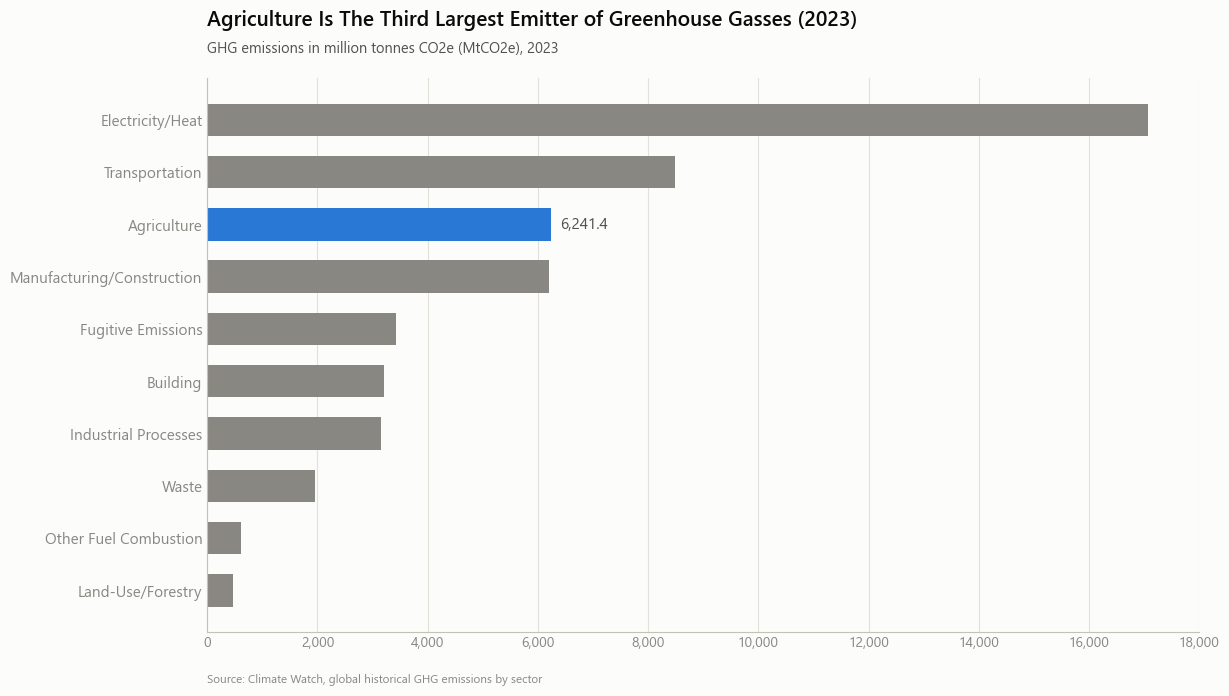

In [3]:
YEAR = 2023
HIGHLIGHT = 'Agriculture'

TITLE_SECTOR = 'Agriculture Is The Third Largest Emitter of Greenhouse Gasses (2023)'
# Alternative that survives the 0.59% margin documented above:
TITLE_SECTOR_ALT = 'Agriculture is among the largest emitters - level with manufacturing (2023)'
SUBTITLE_SECTOR = f'GHG emissions in million tonnes CO2e ({UNIT}), {YEAR}'

# Long source label shortened for the axis, as in the archived EDA notebook.
RENAME = {'Land Use, Land-Use Change and Forestry': 'Land-Use/Forestry'}

s = emissions[YEAR].rename(index=RENAME).sort_values(ascending=True)  # largest ends on top

assert (s >= 0).all(), (
    f'{YEAR} has negative sector values ({list(s[s < 0].index)}); a zero-baseline bar '
    'chart cannot represent a net-negative flux - use a different form for that year')

rank = list(s.sort_values(ascending=False).index).index(HIGHLIGHT) + 1
runner = s.sort_values(ascending=False).iloc[rank]
gap = s[HIGHLIGHT] - runner
assert rank == 3, f'{HIGHLIGHT} is rank {rank} in {YEAR}, but the title claims third'
print(f'{HIGHLIGHT} ranks {rank} in {YEAR}: {s[HIGHLIGHT]:,.2f} vs next {runner:,.2f} '
      f'-> margin {gap:,.2f} {UNIT} ({100 * gap / runner:.2f}%)')

colors = [BLUE if name == HIGHLIGHT else NEUTRAL for name in s.index]

fig, ax = plt.subplots(figsize=(12.8, 7.2))
ax.barh(s.index, s.values, height=0.62, color=colors)

# Direct-label the highlighted bar only - never a number on every bar.
ax.text(s[HIGHLIGHT] + 160, list(s.index).index(HIGHLIGHT), f'{s[HIGHLIGHT]:,.1f}',
        va='center', ha='left', fontsize=11, color=SEC)

style_axes(ax)
xmax = 2000 * int(np.ceil(s.max() / 2000))
ax.set_xlim(0, xmax)
ax.set_xticks(range(0, xmax + 1, 2000))
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_ylim(-0.8, len(s) - 0.2)
ax.tick_params(axis='y', labelsize=11)

add_titles(ax, TITLE_SECTOR, SUBTITLE_SECTOR, SOURCE_CW, source_pts=-30)

fig.savefig(FIGS / 'fig_slide02_sector_bar.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()

## Figure 2 - the agriculture trend and a linear projection (deck slide 3)

An ordinary-least-squares fit on the 34 observed years, extended 20 years past the last
one. Same model and same horizon as `02_sector_content.ipynb`, so the numbers match the
figure currently in the deck.

Three things the chart states rather than implies:

- the projected segment is **dashed and labelled**, so it reads as a model, not a measurement;
- the projection begins at the *fitted* 2023 value (6,115.9), which sits below the *observed*
  2023 value (6,241.4). The visible step is the residual of a straight line against a series
  that has curved upward recently - it is the honest depiction, not a drawing error;
- the fit statistics travel with the figure, in the caption.

A straight line through 34 years is a description of past trend, not a forecast: it carries
no policy, technology, or demand response. The y-axis is deliberately not zero-based, which
is conventional for reading change in a time series.


Equation: y = 34.33x + -63325.01
R2 score: 0.9630
Fitted 2023: 6,115.9 vs observed 2023: 6,241.4 (residual +125.5 MtCO2e)
Projected 2043: 6,802.4 MtCO2e


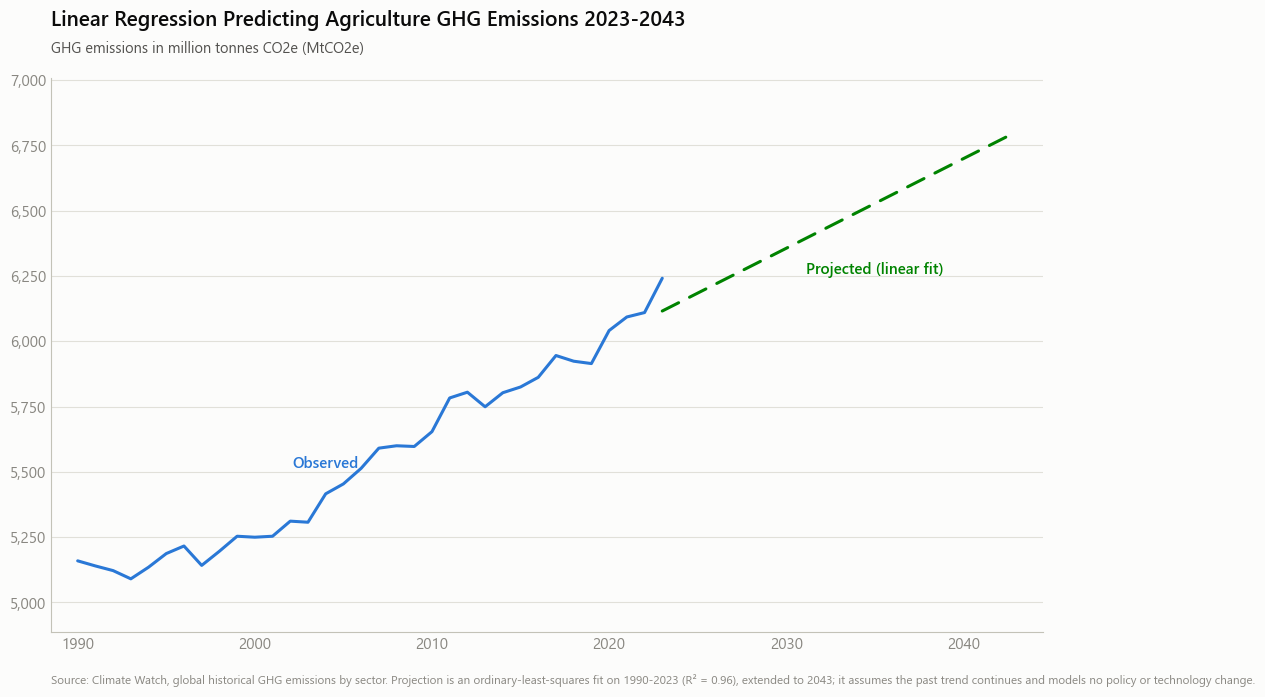

In [4]:
SERIES = 'Agriculture'
HORIZON = 20

TITLE_TREND = f'Linear Regression Predicting Agriculture GHG Emissions {YEAR}-{YEAR + HORIZON}'
SUBTITLE_TREND = f'GHG emissions in million tonnes CO2e ({UNIT})'

obs = emissions.loc[SERIES]
X = obs.index.to_numpy().reshape(-1, 1)
y = obs.to_numpy(dtype=float)

model = LinearRegression().fit(X, y)
slope, intercept, r2 = float(model.coef_[0]), float(model.intercept_), float(model.score(X, y))
print(f'Equation: y = {slope:.2f}x + {intercept:.2f}')
print(f'R2 score: {r2:.4f}')

last = int(obs.index.max())
future_years = np.arange(last, last + HORIZON + 1)
future = model.predict(future_years.reshape(-1, 1))
print(f'Fitted {last}: {future[0]:,.1f} vs observed {last}: {obs.loc[last]:,.1f} '
      f'(residual {obs.loc[last] - future[0]:+,.1f} {UNIT})')
print(f'Projected {future_years[-1]}: {future[-1]:,.1f} {UNIT}')

fig, ax = plt.subplots(figsize=(12.8, 7.2))
ax.plot(obs.index, y, color=BLUE, linewidth=2.2, solid_capstyle='round', zorder=3)
ax.plot(future_years, future, color=GREEN, linewidth=2.2, linestyle=(0, (6, 4)),
        dash_capstyle='round', zorder=3)

# Direct labels: identity never rests on colour alone, and no legend box is needed
# for two segments that are contiguous in time.
ax.annotate('Observed', xy=(2004, obs.loc[2004]), xytext=(0, 16), textcoords='offset points',
            ha='center', va='bottom', fontsize=11, fontweight=600, color=BLUE)
# The drop clears the label's full width, not just its centre: the line is diagonal, so
# it rises back across a horizontal label and would cut through the left half of a
# tighter offset.
ax.annotate('Projected (linear fit)', xy=(2035, model.predict([[2035]])[0]),
            xytext=(0, -42), textcoords='offset points',
            ha='center', va='top', fontsize=11, fontweight=600, color=GREEN)

style_axes_line(ax)
lo, hi = min(y.min(), future.min()), max(y.max(), future.max())
pad = (hi - lo) * 0.12
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlim(min(obs.index) - 1.5, future_years[-1] + 1.5)
ax.set_xticks(range(1990, future_years[-1] + 1, 10))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='both', labelsize=11)

add_titles(ax, TITLE_TREND, SUBTITLE_TREND,
           f'{SOURCE_CW}. Projection is an ordinary-least-squares fit on '
           f'{min(obs.index)}-{last} (R² = {r2:.2f}), extended to {future_years[-1]}; '
           'it assumes the past trend continues and models no policy or technology change.',
           source_pts=-30)

fig.savefig(FIGS / 'fig_slide03_regression.png',
            dpi=200, bbox_inches='tight', facecolor=SURFACE)
plt.show()